In [342]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from scipy import stats

In [343]:
# Load dataset
df = pd.read_csv("soyabean.csv")

In [344]:
# Display basic info
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   season            683 non-null    object
 1   plant_count       683 non-null    object
 2   rainfall          683 non-null    object
 3   temperature       683 non-null    object
 4   hail_damage       579 non-null    object
 5   past_crops        683 non-null    object
 6   damaged_area      683 non-null    object
 7   damage_level      579 non-null    object
 8   seed_treatment    683 non-null    object
 9   seed_germination  683 non-null    object
 10  growth_stage      683 non-null    object
 11  leaf_health       683 non-null    object
 12  halo_spots        683 non-null    object
 13  spot_edges        683 non-null    object
 14  spot_size         683 non-null    object
 15  leaf_tearing      683 non-null    object
 16  leaf_deformity    683 non-null    object
 17  leaf_yellowing  

None

In [345]:
df.shape

(683, 36)

In [346]:
display(df.head())

,season,plant_count,rainfall,temperature,hail_damage,past_crops,damaged_area,damage_level,seed_treatment,seed_germination,...,fungal_nodes,pod_health,pod_spots,seed_health,mold_on_seed,seed_spots,seed_size,shriveled_seeds,root_health,disease_type
0,october,normal,gt-norm,norm,yes,same-lst-yr,low-areas,pot-severe,none,90-100,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
1,august,normal,gt-norm,norm,yes,same-lst-two-yrs,scattered,severe,fungicide,80-89,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
2,july,normal,gt-norm,norm,yes,same-lst-yr,scattered,severe,fungicide,lt-80,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
3,july,normal,gt-norm,norm,yes,same-lst-yr,scattered,severe,none,80-89,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
4,october,normal,gt-norm,norm,yes,same-lst-two-yrs,scattered,pot-severe,none,lt-80,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker


In [347]:
df.columns

Index(['season', 'plant_count', 'rainfall', 'temperature', 'hail_damage',
       'past_crops', 'damaged_area', 'damage_level', 'seed_treatment',
       'seed_germination', 'growth_stage', 'leaf_health', 'halo_spots',
       'spot_edges', 'spot_size', 'leaf_tearing', 'leaf_deformity',
       'leaf_yellowing', 'stem_health', 'plant_tilt', 'stem_sores',
       'lesion_size', 'fungal_growth', 'outer_rot', 'fungus_growth',
       'inside_discolor', 'fungal_nodes', 'pod_health', 'pod_spots',
       'seed_health', 'mold_on_seed', 'seed_spots', 'seed_size',
       'shriveled_seeds', 'root_health', 'disease_type'],
      dtype='object')

In [348]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
hail_damage        104
damage_level       104
fungal_growth      107
pod_health          84
pod_spots          106
seed_health         92
mold_on_seed        92
seed_spots         106
seed_size           92
shriveled_seeds    105
dtype: int64


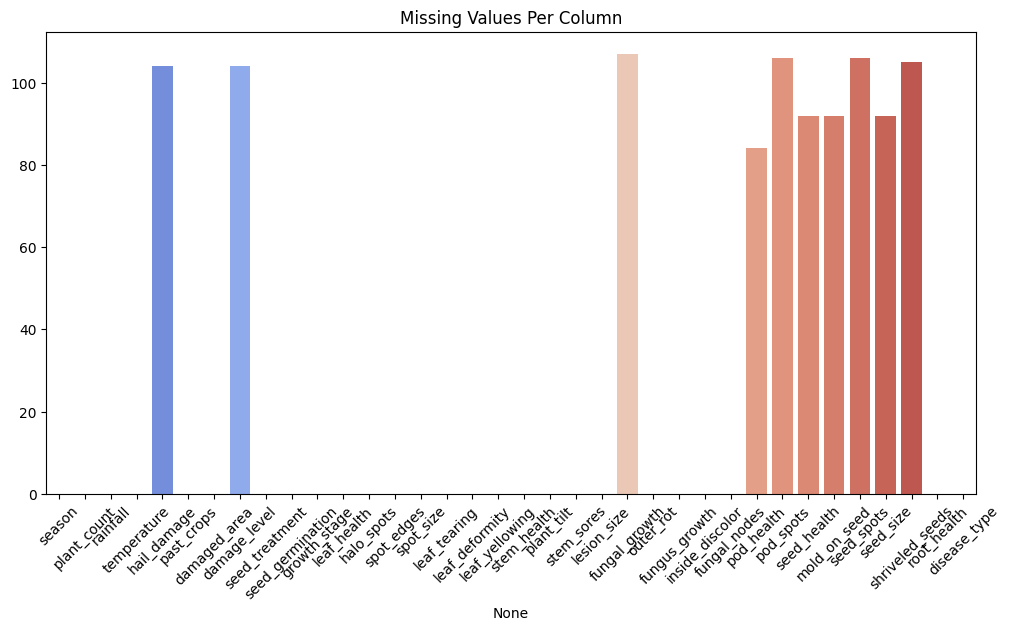

In [349]:
# Visualize missing values
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.index, y=missing_values.values,hue=missing_values.index, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Missing Values Per Column")
plt.show()

In [350]:
# Data Type Analysis
data_types = df.dtypes.value_counts()
print("Column Data Types:")
for dtype, count in data_types.items():
    print(f"{dtype}: {count}")

Column Data Types:
object: 36


In [351]:
# Handling Missing Values using SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [352]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", [missing_values])

Missing Values per Column:
 [season              0
plant_count         0
rainfall            0
temperature         0
hail_damage         0
past_crops          0
damaged_area        0
damage_level        0
seed_treatment      0
seed_germination    0
growth_stage        0
leaf_health         0
halo_spots          0
spot_edges          0
spot_size           0
leaf_tearing        0
leaf_deformity      0
leaf_yellowing      0
stem_health         0
plant_tilt          0
stem_sores          0
lesion_size         0
fungal_growth       0
outer_rot           0
fungus_growth       0
inside_discolor     0
fungal_nodes        0
pod_health          0
pod_spots           0
seed_health         0
mold_on_seed        0
seed_spots          0
seed_size           0
shriveled_seeds     0
root_health         0
disease_type        0
dtype: int64]


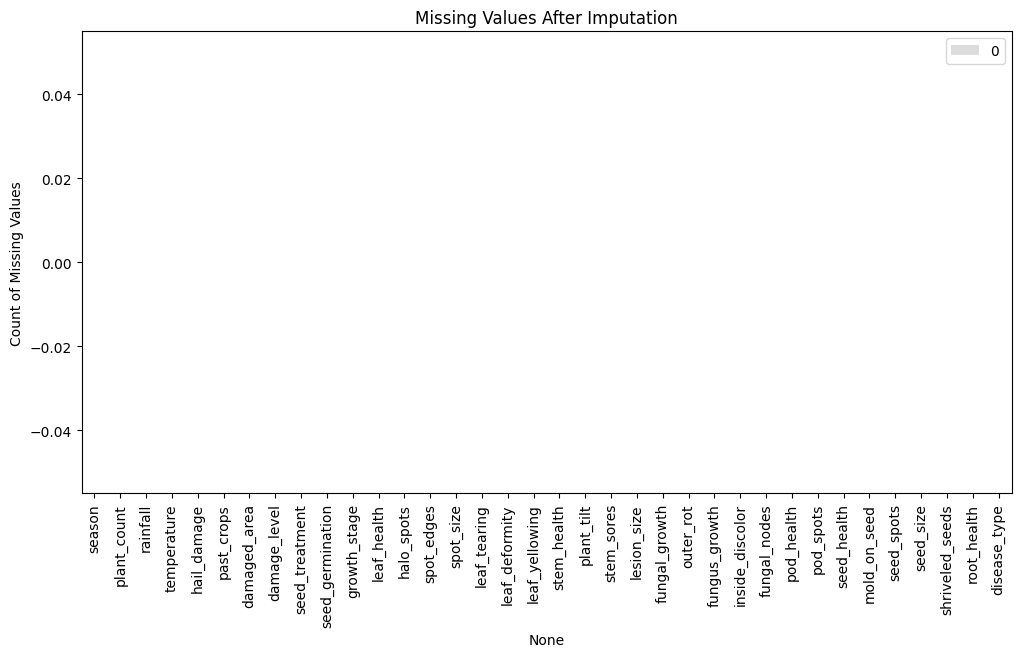

In [353]:
# Visualizing Distribution of Imputed Values
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.index, y=df.isnull().sum().values,hue=df.isnull().sum().values, palette='coolwarm')
plt.xticks(rotation=90)
plt.title("Missing Values After Imputation")
plt.ylabel("Count of Missing Values")
plt.show()

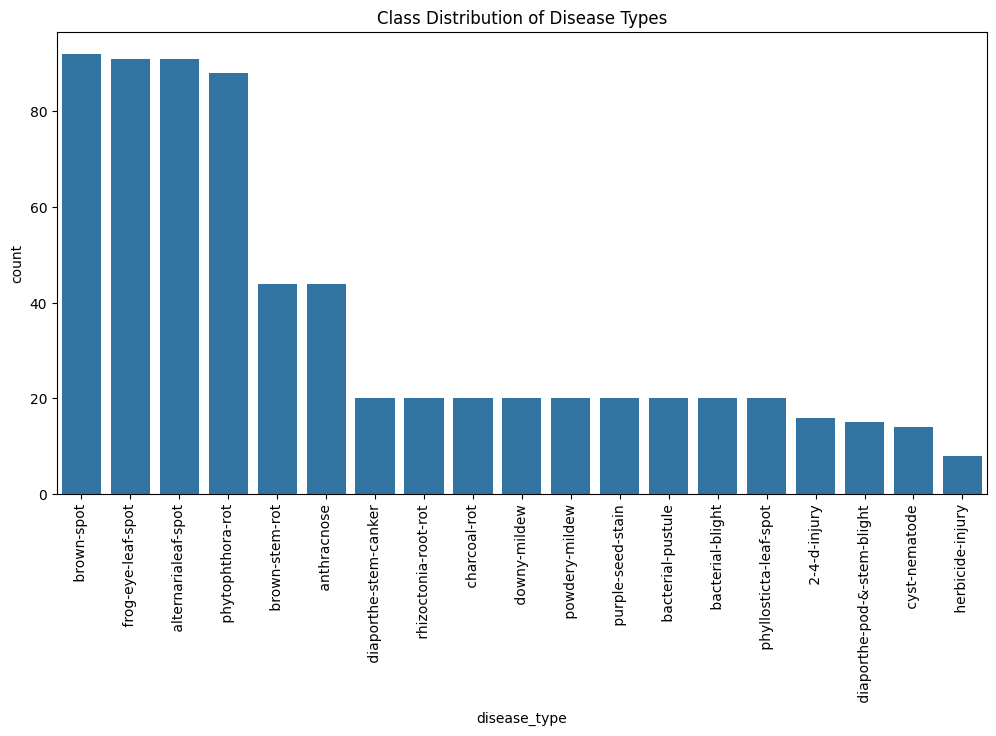

In [354]:
# Visualizing Class Distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='disease_type', data=df, order=df['disease_type'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Class Distribution of Disease Types")
plt.show()

In [355]:
# Encoding Categorical Variables
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

In [356]:
df.head()

,season,plant_count,rainfall,temperature,hail_damage,past_crops,damaged_area,damage_level,seed_treatment,seed_germination,...,fungal_nodes,pod_health,pod_spots,seed_health,mold_on_seed,seed_spots,seed_size,shriveled_seeds,root_health,disease_type
0,6,2,1,3,2,4,1,2,2,1,...,0,3,3,1,0,0,1,1,1,10
1,2,2,1,3,2,3,2,3,1,0,...,0,3,3,1,0,0,1,1,1,10
2,3,2,1,3,2,4,2,3,1,3,...,0,3,3,1,0,0,1,1,1,10
3,3,2,1,3,2,4,2,3,2,0,...,0,3,3,1,0,0,1,1,1,10
4,6,2,1,3,2,3,2,2,2,3,...,0,3,3,1,0,0,1,1,1,10


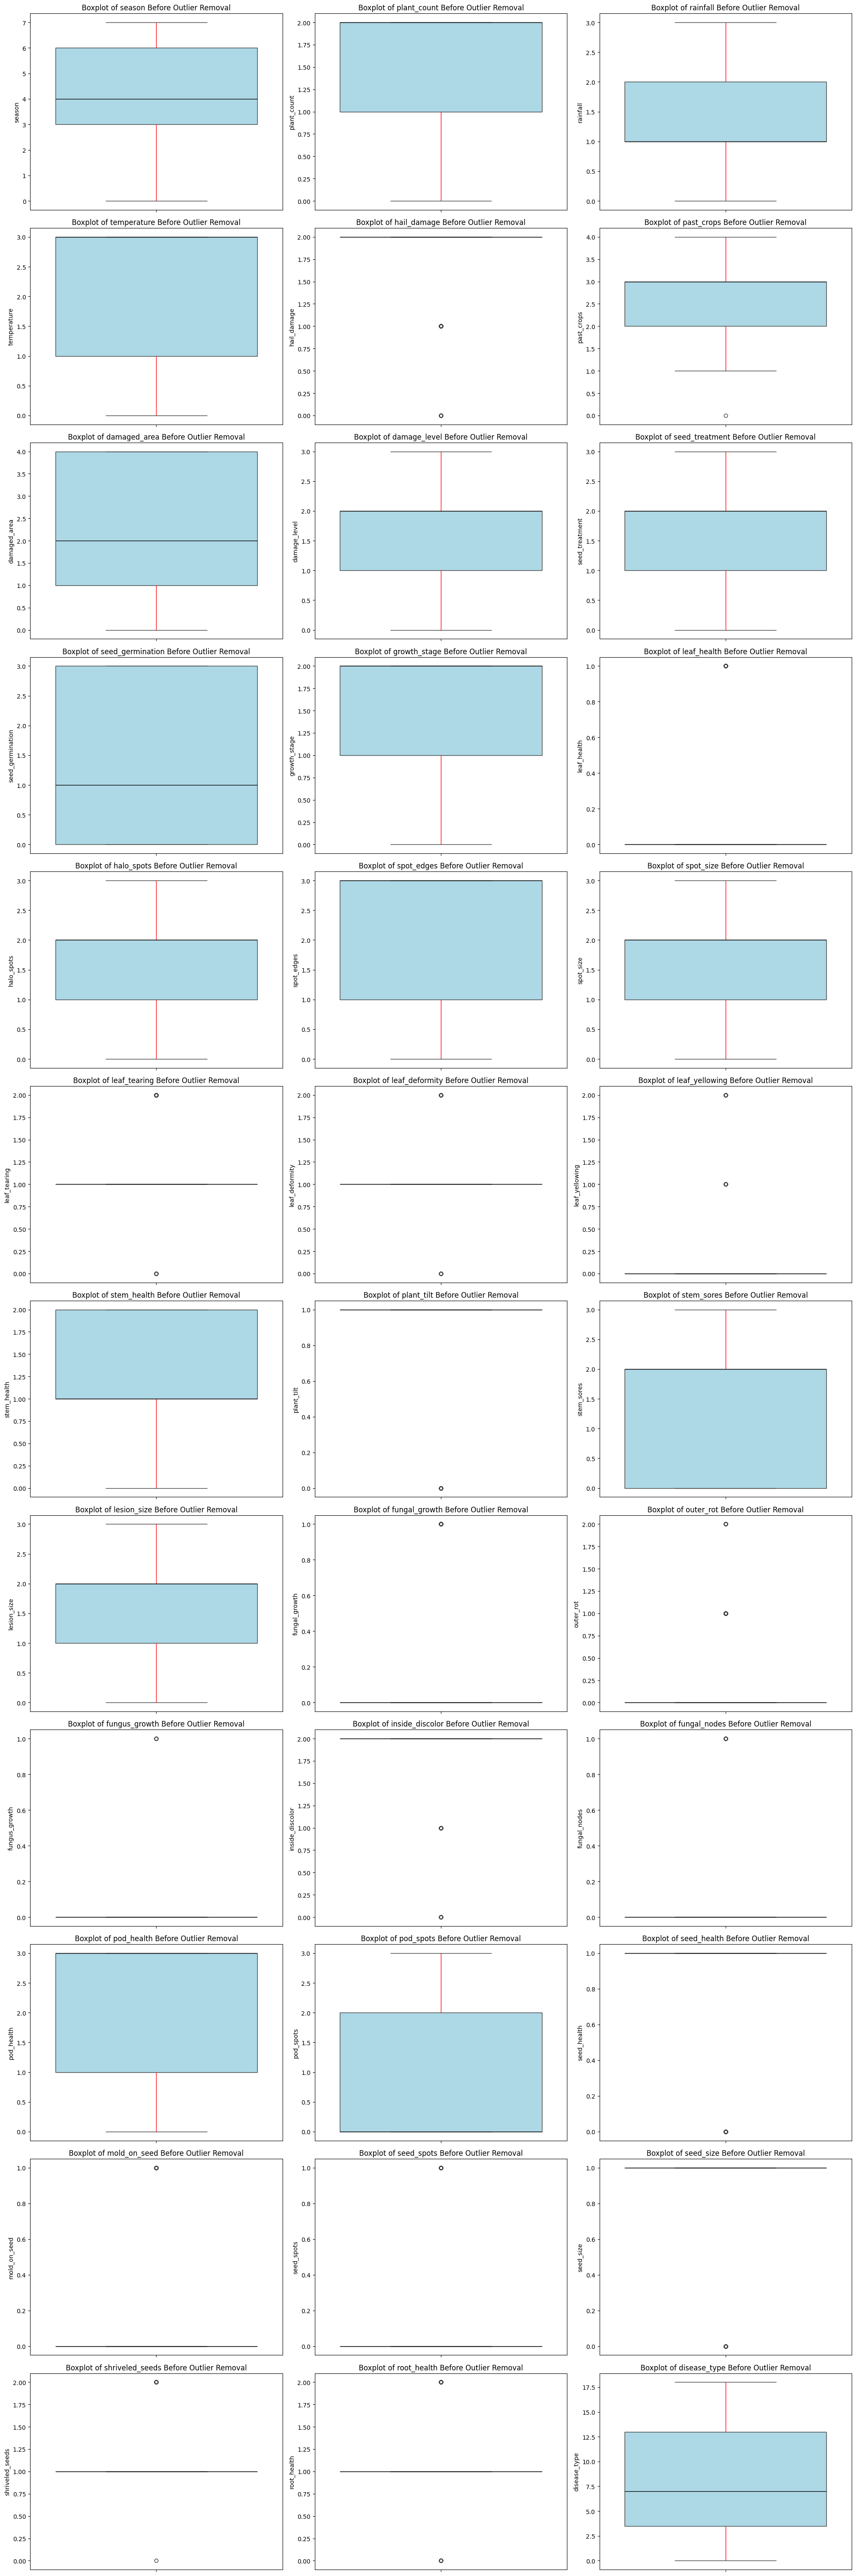

In [357]:
# Select numerical columns
num_cols = df.select_dtypes(include=['number']).columns

# Improved Boxplot Visualization Before Outlier Removal
num_plots = len(num_cols)
num_cols_per_row = 3
num_rows = -(-num_plots // num_cols_per_row)  # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(20, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], showcaps=True, 
                boxprops={'facecolor':'lightblue'}, 
                whiskerprops={'color':'red'}, medianprops={'color':'black'})
    axes[i].set_title(f"Boxplot of {col} Before Outlier Removal")
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [358]:
# Handling Outliers using IQR Method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clip values instead of dropping rows
df_cleaned = df.copy()
df_cleaned[num_cols] = df_cleaned[num_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)

print(f"Data Shape After IQR Clipping: {df_cleaned.shape}")

Data Shape After IQR Clipping: (683, 36)


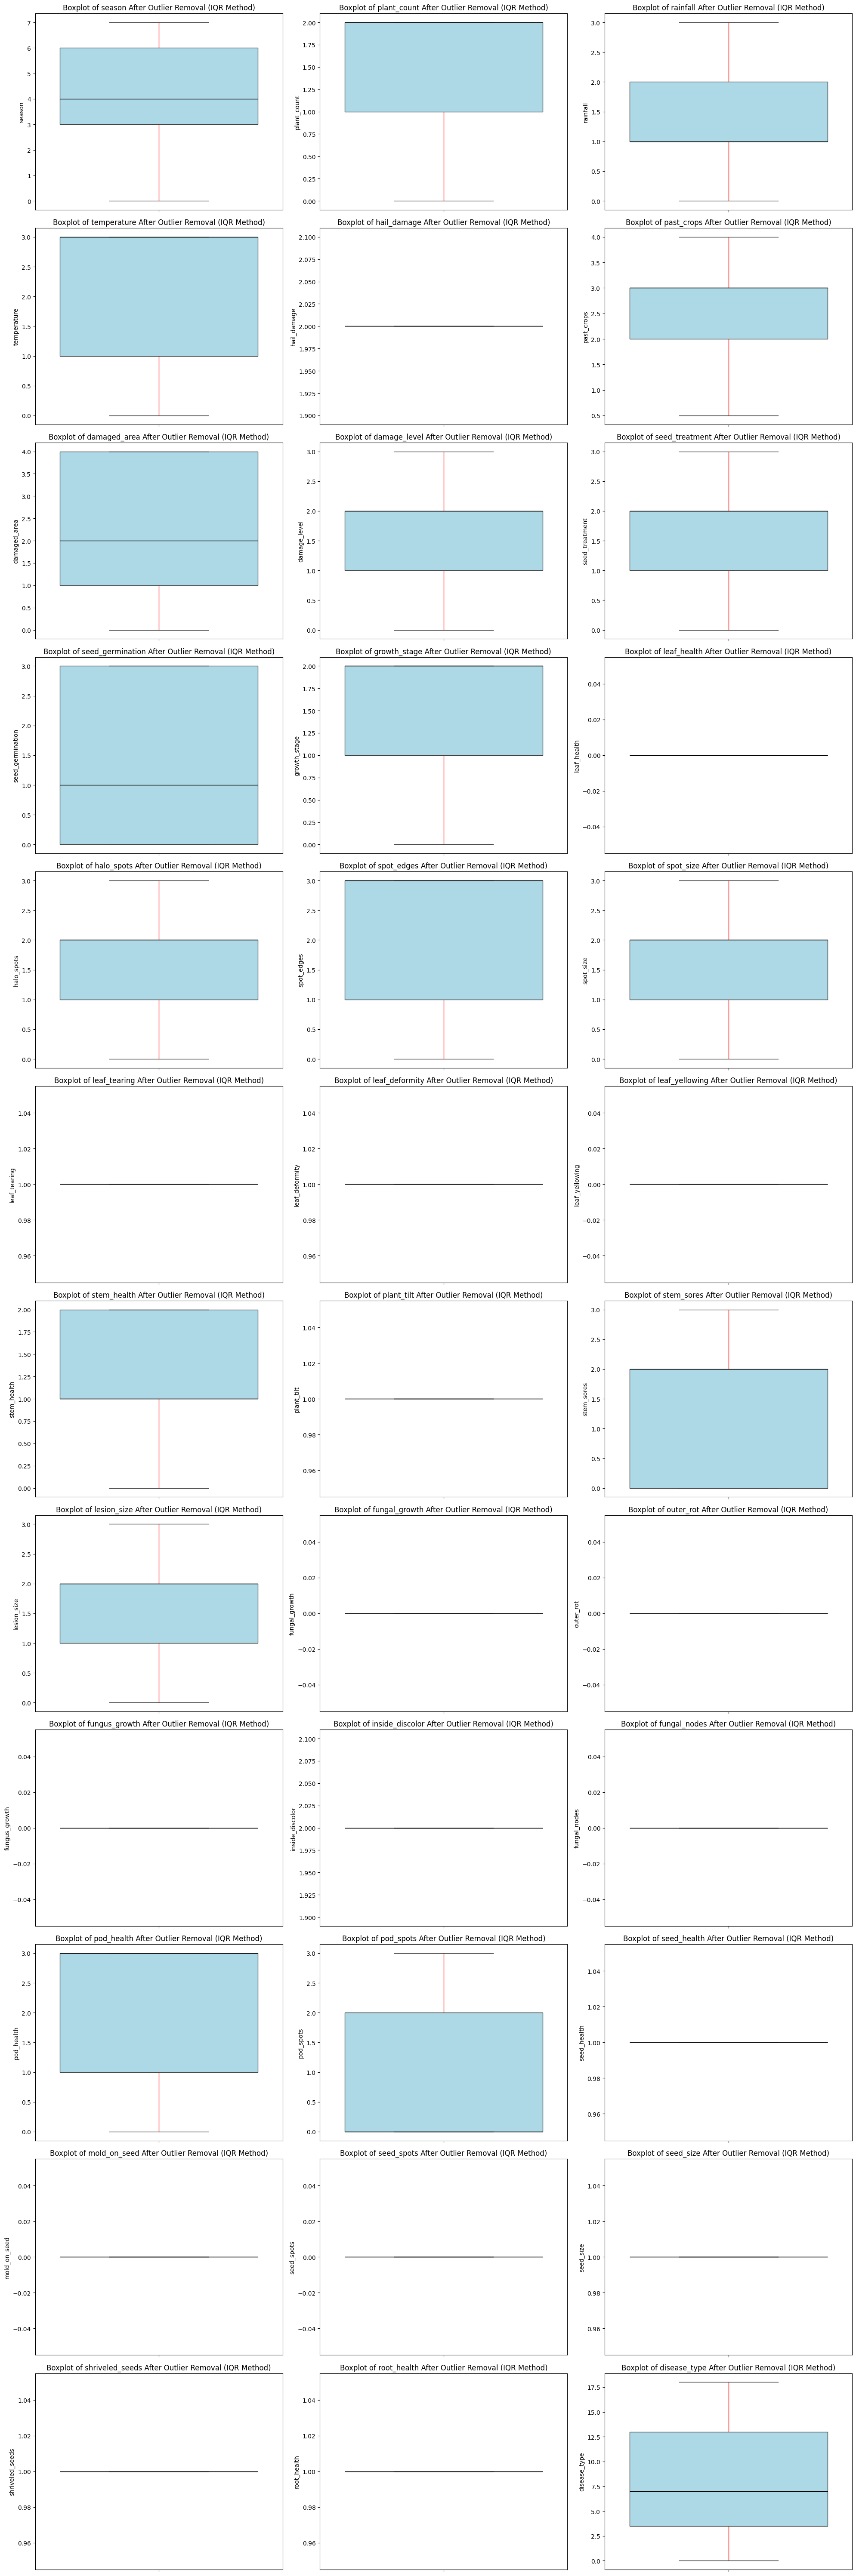

In [359]:
# Boxplot for each numerical feature after outlier removal
fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(20, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df_cleaned[col], ax=axes[i], showcaps=True, 
                boxprops={'facecolor':'lightblue'}, 
                whiskerprops={'color':'red'}, medianprops={'color':'black'})
    axes[i].set_title(f"Boxplot of {col} After Outlier Removal (IQR Method)")
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

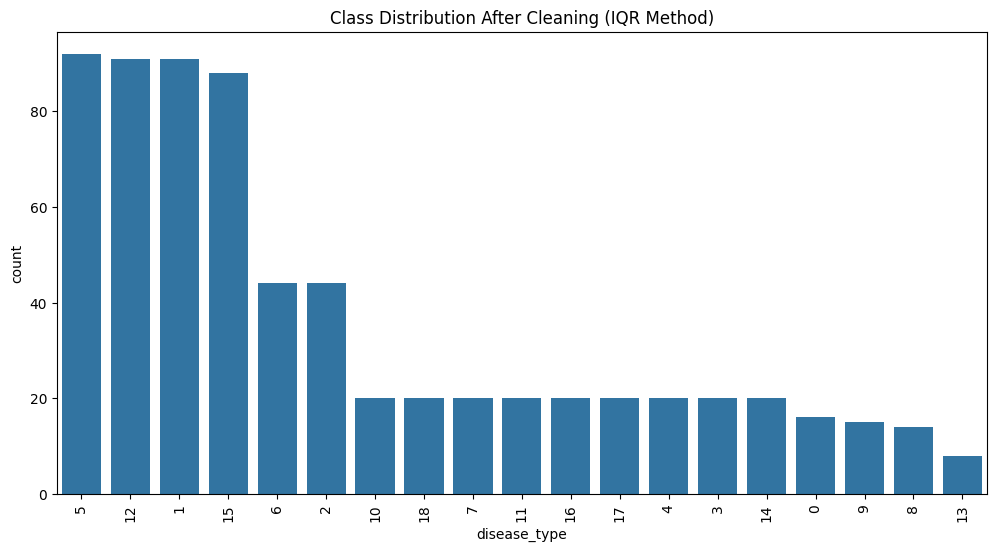

In [360]:
# Checking Balance of Dataset
plt.figure(figsize=(12, 6))
sns.countplot(x='disease_type', data=df_cleaned, order=df_cleaned['disease_type'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Class Distribution After Cleaning (IQR Method)")
plt.show()

In [361]:
# Handling Imbalance using SMOTE
X = df_cleaned.drop(columns=['disease_type'])
y = df_cleaned['disease_type']
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

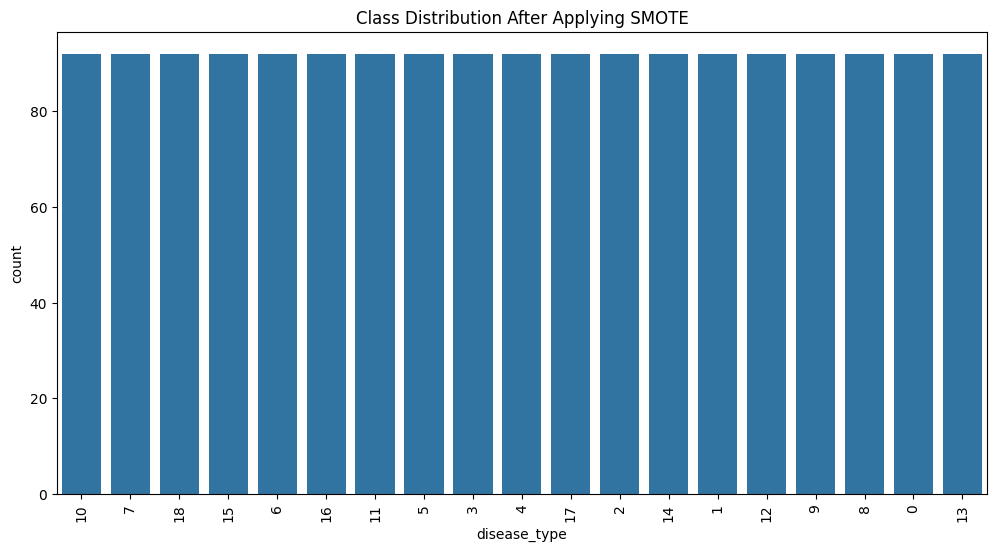

In [362]:
# Plot Class Distribution After SMOTE
plt.figure(figsize=(12, 6))
sns.countplot(x=y_resampled, order=pd.Series(y_resampled).value_counts().index)
plt.xticks(rotation=90)
plt.title("Class Distribution After Applying SMOTE")
plt.show()

In [363]:
# Display the shape of the resampled dataset
print("Shape of dataset before SMOTE:", X.shape)
print("Shape of dataset after SMOTE:", X_resampled.shape)

Shape of dataset before SMOTE: (683, 35)
Shape of dataset after SMOTE: (1748, 35)


In [364]:
# Display first few rows of the resampled dataset
print("\nFirst few rows of the resampled dataset:")
display(pd.DataFrame(X_resampled, columns=X.columns).head())


First few rows of the resampled dataset:


,season,plant_count,rainfall,temperature,hail_damage,past_crops,damaged_area,damage_level,seed_treatment,seed_germination,...,inside_discolor,fungal_nodes,pod_health,pod_spots,seed_health,mold_on_seed,seed_spots,seed_size,shriveled_seeds,root_health
0,6,2,1,3,2,4.0,1,2,2,1,...,2,0,3,3,1,0,0,1,1,1
1,2,2,1,3,2,3.0,2,3,1,0,...,2,0,3,3,1,0,0,1,1,1
2,3,2,1,3,2,4.0,2,3,1,3,...,2,0,3,3,1,0,0,1,1,1
3,3,2,1,3,2,4.0,2,3,2,0,...,2,0,3,3,1,0,0,1,1,1
4,6,2,1,3,2,3.0,2,2,2,3,...,2,0,3,3,1,0,0,1,1,1


In [365]:
# Pair Plot for Numerical Features
sns.pairplot(pd.DataFrame(X_resampled, columns=X.columns))
plt.show()

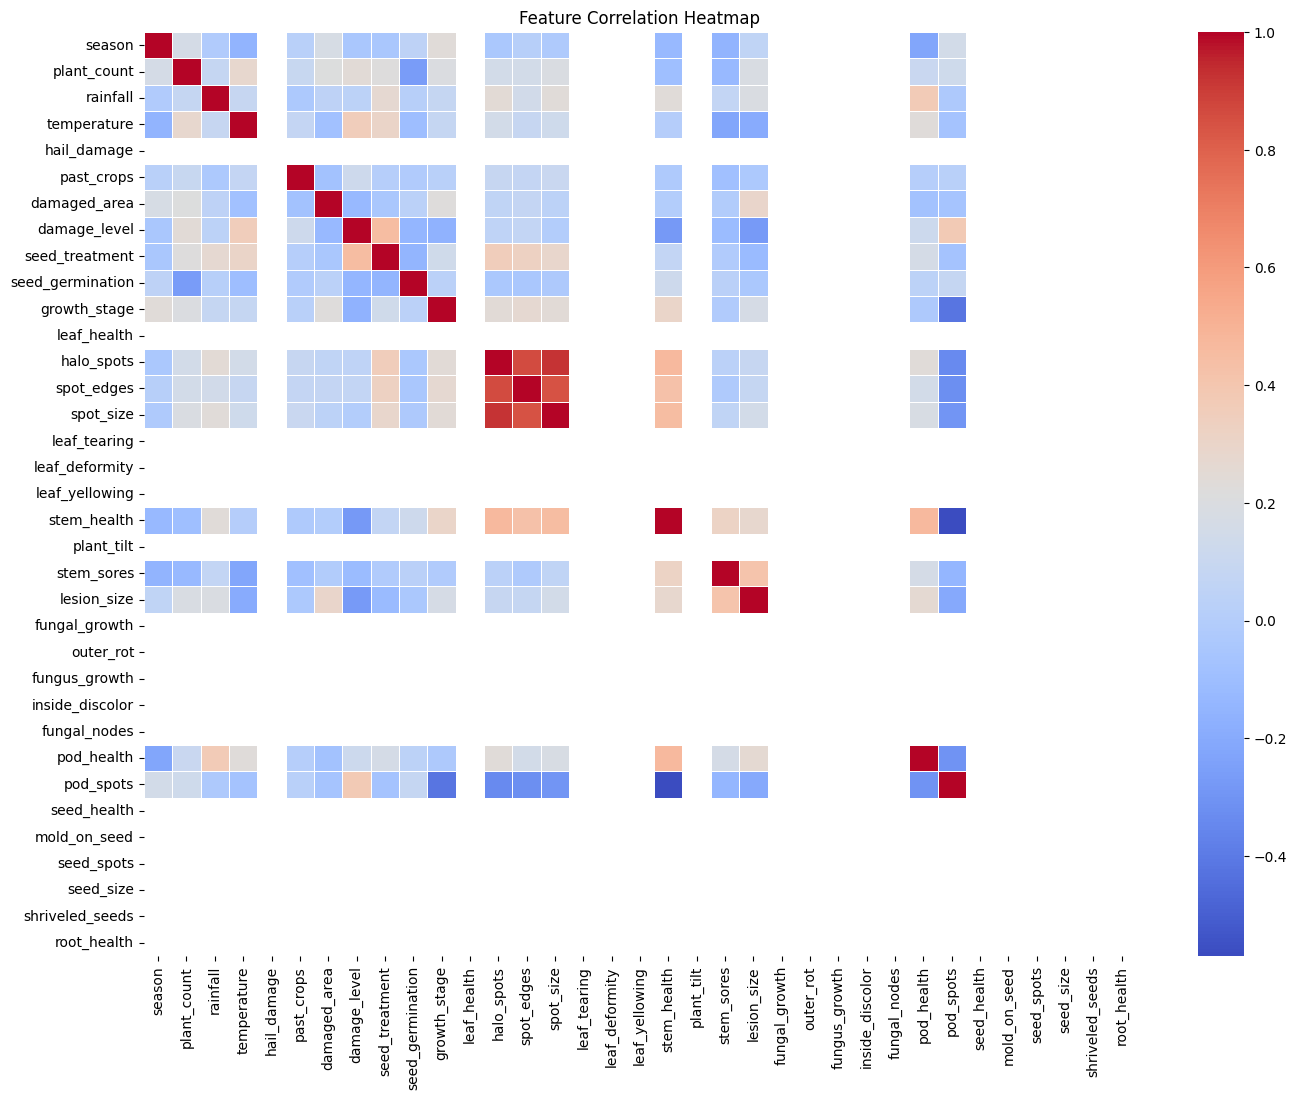

In [366]:
# Improved Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(X_resampled.corr(), annot=False, cmap='coolwarm', linewidths=0.5, cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [367]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, chi2
from sklearn.ensemble import RandomForestClassifier

In [368]:
# Identify and Remove Highly Correlated Features (Threshold > 0.85)
corr_matrix = X_resampled.corr().abs()
high_corr_features = set()
threshold = 0.85
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            high_corr_features.add(colname)
X_resampled = X_resampled.drop(columns=high_corr_features)
print("Removed highly correlated features:", high_corr_features)

Removed highly correlated features: {'spot_size', 'spot_edges'}


In [369]:
# Chi-Square Test: Select Features with p-value < 0.05
chi_scores, p_values = chi2(X_resampled, y_resampled)
chi_selected_features = X_resampled.columns[p_values < 0.05].tolist()
print("Selected Features using Chi-Square (p < 0.05):", chi_selected_features)

Selected Features using Chi-Square (p < 0.05): ['season', 'plant_count', 'rainfall', 'temperature', 'damaged_area', 'damage_level', 'seed_treatment', 'seed_germination', 'growth_stage', 'halo_spots', 'stem_health', 'stem_sores', 'lesion_size', 'pod_health', 'pod_spots']


In [370]:
# Mutual Information: Select Features with MI > 0.05
mi_scores = mutual_info_classif(X_resampled, y_resampled)
mi_scores_series = pd.Series(mi_scores, index=X_resampled.columns)
mi_selected_features = mi_scores_series[mi_scores_series > 0.05].index.tolist()
print("Selected Features using Mutual Information (MI > 0.05):", mi_selected_features)

Selected Features using Mutual Information (MI > 0.05): ['season', 'plant_count', 'rainfall', 'temperature', 'past_crops', 'damaged_area', 'damage_level', 'seed_treatment', 'seed_germination', 'growth_stage', 'halo_spots', 'stem_health', 'stem_sores', 'lesion_size', 'pod_health', 'pod_spots']


In [371]:
# Random Forest Feature Importance: Select Features with Importance > 0.05
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_resampled, y_resampled)
feature_importances = pd.Series(rf.feature_importances_, index=X_resampled.columns)
rf_selected_features = feature_importances[feature_importances > 0.05].index.tolist()
print("Selected Features using Random Forest (Importance > 0.05):", rf_selected_features)

Selected Features using Random Forest (Importance > 0.05): ['season', 'plant_count', 'rainfall', 'temperature', 'damaged_area', 'growth_stage', 'halo_spots', 'stem_sores', 'lesion_size', 'pod_health', 'pod_spots']


In [372]:
# Selecting Final Features based on all methods
selected_features = list(set(chi_selected_features + mi_selected_features + rf_selected_features))
X_resampled = X_resampled[selected_features]

In [373]:
# Print final selected features
print("Final Selected Features:", selected_features)

Final Selected Features: ['stem_health', 'temperature', 'damage_level', 'seed_treatment', 'seed_germination', 'halo_spots', 'lesion_size', 'plant_count', 'season', 'growth_stage', 'pod_spots', 'stem_sores', 'pod_health', 'past_crops', 'rainfall', 'damaged_area']


In [374]:
# Feature Scaling (Standardization) - Only if using SVM, Logistic Regression
scaler = StandardScaler()
X_resampled = pd.DataFrame(scaler.fit_transform(X_resampled), columns=X_resampled.columns)

In [375]:
# Final Processed Data
final_df = pd.DataFrame(X_resampled, columns=X_resampled.columns)
final_df['disease_type'] = y_resampled
print("Final Processed Data Shape:", final_df.shape)

Final Processed Data Shape: (1748, 17)


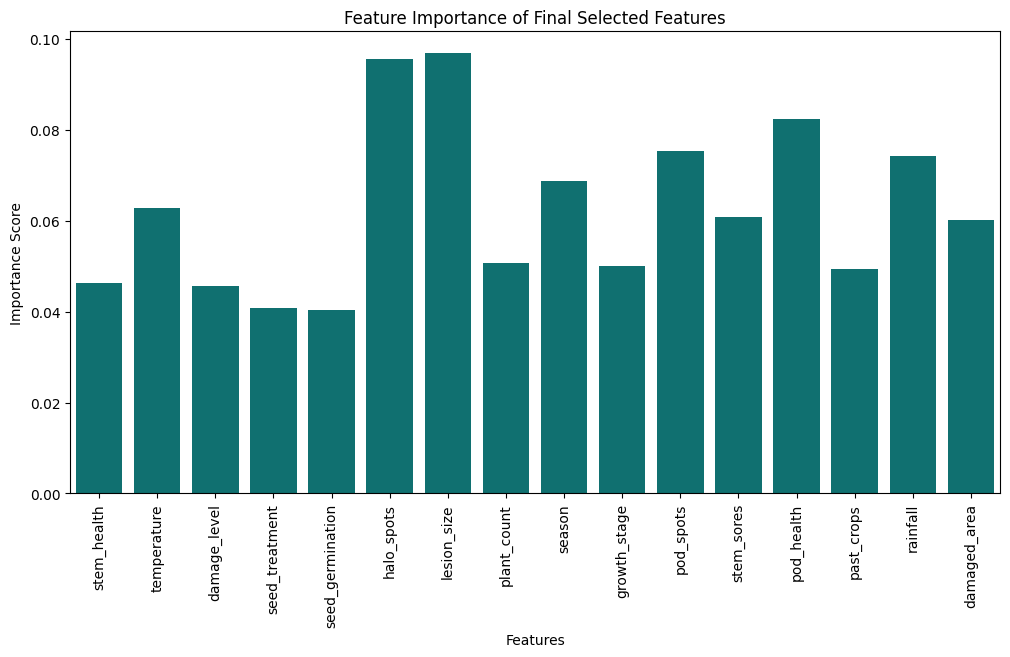

In [376]:
# Visualizing Final Selected Features
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances[selected_features].index, y=feature_importances[selected_features].values, color='teal')
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance of Final Selected Features")
plt.show()

In [377]:
import pickle
# Save Processed Data to Pickle File
with open("processed_data.pkl", "wb") as file:
    pickle.dump(final_df, file)
print("Processed data saved as 'processed_data.pkl'")

Processed data saved as 'processed_data.pkl'
